# Classification

### Import the data

In [2]:
!pip install keras
!pip install tensorflow


  Using cached tensorflow-2.18.0-cp39-cp39-win_amd64.whl.metadata (3.3 kB)
  Using cached tensorflow_intel-2.18.0-cp39-cp39-win_amd64.whl.metadata (4.9 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-24.12.23-py2.py3-none-any.whl.metadata (876 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-2.5.0-py3-none-any.whl.metadata (6.1 kB)
  Using cached grpcio-1.69.0-cp39-cp39-win_amd64.whl.metadata (4.0 kB)
  Using cached tensorboard-2.18.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached ml_dtypes-0.4.1-cp39-cp39-win_amd64.whl.metadata (20 kB)
  Using cached tensorflow_io_gcs_filesystem-0.31.0-cp39-cp39-win_amd64.whl.metadata (14 kB)
  Using cached tensorboard_data_server-0.7.2-py3-

In [3]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [4]:
x_train.shape

(60000, 28, 28)

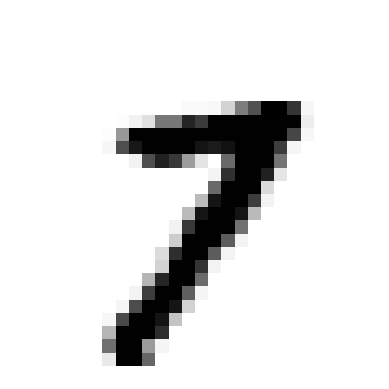

In [6]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

some_digit = x_train[40000]

plt.imshow(some_digit, cmap=matplotlib.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show()

In [7]:
y_train[40000]

7

### Shuffling the training set

Some learning algorithms are sensitive to the order of the training instances, and they perform poorly if they get many similar instances in a row.

Shuffling dataset ensures that this won't happen.

In [9]:
import numpy as np

shuffle_index = np.random.permutation(60000)
x_train, y_train = x_train[shuffle_index], y_train[shuffle_index]

In [11]:
y_train[26890]

0

## Training a Binary Classifier

A binary classifier is capable of distinguishing between just 2 classes.

Let's create abinary classifier to identify 2 and not-2

In [12]:
y_train_2 = (y_train == 2)
y_test_2 = (y_test == 2)

In [16]:
y_train_2[21714]

False

Let's train a **Stochastic Gradient Descent(SGD)** classifier.

Scikit-learn's SGDClassifier is capable of handling very large datasets efficiently.

SGD deals with training instances independently, one at a time.

In [20]:
from sklearn.linear_model import SGDClassifier

x_train_reshaped = x_train.reshape(60000,784)
sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(x_train_reshaped, y_train_2)

SGDClassifier(random_state=42)

In [22]:
sgd_clf.predict([some_digit.reshape(784)])

array([False])

## Performance Measures